# Importing the libraries

In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import warnings
import joblib
warnings.filterwarnings('ignore')

# Data collection and processing

#### Loading the csv data into Pandas DataFrame

In [29]:
df = pd.read_csv('../data/raw/gold_price_data.csv')

Printing the first 5 rows in the dataframe

In [30]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


Printing the last 5 rows in the datframe

In [31]:
df.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


Number of rows and columns in the dataframe

In [32]:
df.shape

(2290, 6)

Getting some basic informations about the data

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


Checking the number of missing values

In [34]:
df.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

Getting the statistical measures of the data

In [35]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Correlation :
1. Positive Correlation
2. Negative Correlation

In [36]:
correlation = df.select_dtypes(include=['number']).corr()

Constructing a heatmap to understand the correlation

<Axes: >

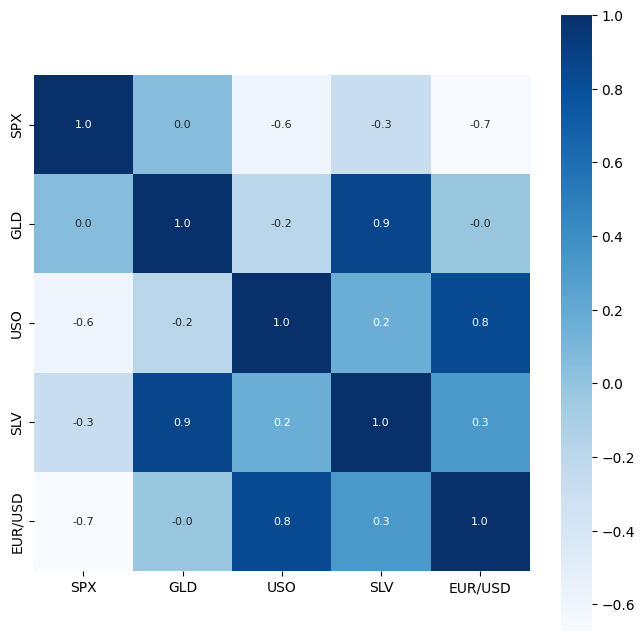

In [37]:
plt.figure(figsize=(8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt=".1f", annot=True, annot_kws={'size':8}, cmap="Blues")

Correlation values of GLD

In [38]:
correlation['GLD'].sort_values(ascending=False)

GLD        1.000000
SLV        0.866632
SPX        0.049345
EUR/USD   -0.024375
USO       -0.186360
Name: GLD, dtype: float64

Check the distribution of the GLD price

<Axes: xlabel='GLD', ylabel='Density'>

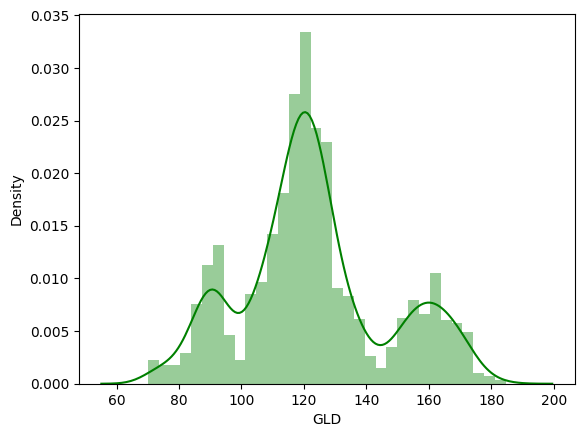

In [39]:
sns.distplot(df["GLD"], color="Green")

Splitting the features and target


In [40]:
X = df.drop(columns=["Date","GLD"], axis=1)
y = df["GLD"]

Splitting into training and testing data

In [41]:
X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=2)

Model training: Random Forest Regressor

In [42]:
regressor = RandomForestRegressor(n_estimators=100)

Training the model

In [43]:
regressor.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Model evaluation

In [44]:
test_data_prediction = regressor.predict(X_test)

In [45]:
test_data_prediction

array([168.41599915,  81.97839984, 116.02540029, 127.56190076,
       120.7721013 , 154.70989769, 150.58909891, 125.99660033,
       117.51429878, 126.1840006 , 116.78790048, 171.5578009 ,
       141.46919925, 167.94609848, 115.27740012, 118.09790031,
       139.22400266, 170.09650103, 159.45640297, 158.91650011,
       155.17330012, 125.08780015, 176.04279916, 157.7032033 ,
       125.25740042,  93.80939985,  76.8431002 , 120.78630005,
       119.11059914, 167.44579928,  88.08490051, 125.2347    ,
        91.11480085, 117.6811003 , 121.20529906, 136.39110049,
       115.40260103, 115.05540085, 148.9353001 , 107.59380099,
       103.92220197,  87.28439795, 126.47900059, 117.98350022,
       152.1288988 , 119.66449985, 108.33840003, 108.30009813,
        93.16150025, 127.11019792,  75.01870021, 113.67769934,
       121.47300012, 111.32119924, 118.90519922, 121.12279921,
       159.00820042, 168.11010178, 146.72409665,  86.01219865,
        94.25770039,  86.80569847,  90.51840075, 119.02

R squared error


In [46]:
error_score = metrics.r2_score(y_test, test_data_prediction)
error_score

0.9890407743353942

Compare the Actual and Predicted values in a plot

In [47]:
y_test = list(y_test)

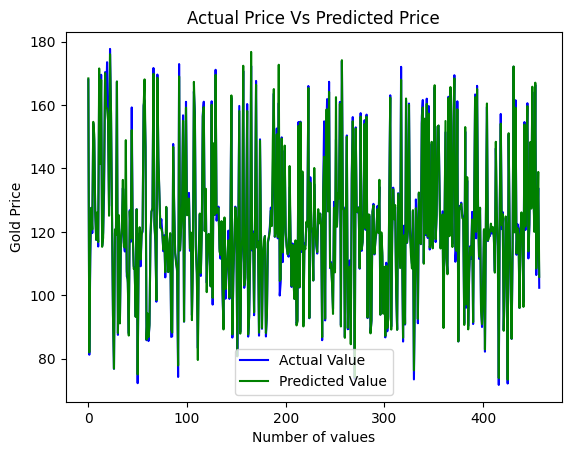

In [48]:
plt.plot(y_test, color="blue", label ="Actual Value")
plt.plot(test_data_prediction, color="green",label="Predicted Value")
plt.title("Actual Price Vs Predicted Price")
plt.xlabel("Number of values")
plt.ylabel("Gold Price")
plt.legend()
plt.show()